# Days 21-30: Evaluation Metrics

**Not built from `describe.csv`.** That file is a `.describe()` summary (per-column
count/mean/std/min/max) — there is no `y_true`/`y_pred` pair in a stats table, so no evaluation
metric can be computed from it directly. This notebook evaluates the classifiers trained in
`Classification_models.ipynb`, using the `ytest`/`ypred` pairs already saved to
`../Results/classifications.pkl`.

**Hard dependency, not enforced by code:** this notebook will crash on load if
`Classification_models.ipynb` hasn't been run at least once. That's a real coupling between two
notebooks with no guard rail — if you ever reorder or delete the earlier notebook, this one silently
breaks. Worth a `try/except` with a clear error message if this repo grows past a hobby project.

## The 7 metrics covered

| # | Metric | What it actually tells you | Where it lies to you |
|---|--------|------------------------------|------------------------|
| 1 | Accuracy | Fraction of predictions correct | Meaningless on imbalanced classes — 90% accuracy can mean "always predicts majority class" |
| 2 | Precision (weighted) | Of predicted-positive, how many were right, averaged by class support | Weighting by support means a large easy class can hide failure on small hard classes |
| 3 | Recall (weighted) | Of actual-positive, how many were caught, averaged by class support | Same blind spot as precision — support-weighted, not class-fair |
| 4 | F1 (weighted) | Harmonic mean of precision/recall | Inherits both blind spots above |
| 5 | Confusion Matrix | The only metric here that shows *which* classes get confused with *which* | Not a scalar — can't rank models on it directly, but ignoring it means trusting a summary number blind |
| 6 | Cohen's Kappa | Agreement with ground truth *corrected for chance agreement* | A model that "looks" 80% accurate can have mediocre Kappa if that accuracy is inflated by class imbalance |
| 7 | Matthews Correlation Coefficient (MCC) | Balanced measure using all four confusion-matrix quadrants (TP/TN/FP/FN), reliable even under class imbalance | Less intuitive to explain to a non-technical stakeholder — the tradeoff for being harder to game |

Macro-averaged F1 is also computed as a bonus check (not one of the 7) — specifically to
cross-check whether weighted F1 is hiding a minority-class failure. If macro F1 is much lower
than weighted F1 for a model, that model is quietly failing on at least one class.

## 1. Imports

In [1]:
%run ../Imports.py
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef, ConfusionMatrixDisplay

%run ../saving_functions.py
%run ../evaluation_functions.py

## 2. Data

Loading the already-fitted classification results (not raw data — see note above).

In [2]:
try:
    results = loading_classification_results()
except FileNotFoundError:
    raise FileNotFoundError(
        "../Results/classifications.pkl not found. Run Classification_models.ipynb first -- "
        "this notebook has a hard dependency on it and cannot evaluate anything from describe.csv "
        "or raw data alone."
    )

list(results.keys())

['logreg_TypeName',
 'knn_TypeName',
 'dtree_TypeName',
 'rf_TypeName',
 'svc_TypeName']

## 3. Analysis

In [3]:
sns.set_theme()
sns.set_context("paper")

results = add_extra_metrics(results)

metrics_table = pd.DataFrame({
    name: {
        'accuracy': r['accuracy'],
        'precision_weighted': r['precision_weighted'],
        'recall_weighted': r['recall_weighted'],
        'f1_weighted': r['f1_weighted'],
        'cohen_kappa': r['cohen_kappa'],
        'mcc': r['mcc'],
        'f1_macro (bonus check)': r['f1_macro'],
    }
    for name, r in results.items()
}).T

metrics_table

,accuracy,precision_weighted,recall_weighted,f1_weighted,cohen_kappa,mcc,f1_macro (bonus check)
logreg_TypeName,0.811765,0.811044,0.811765,0.806947,0.696962,0.698885,0.755265
knn_TypeName,0.792157,0.771172,0.792157,0.780165,0.659297,0.661490,0.566474
dtree_TypeName,0.811765,0.813952,0.811765,0.811654,0.698329,0.698888,0.682548
rf_TypeName,0.882353,0.882725,0.882353,0.879597,0.811186,0.812364,0.775591
svc_TypeName,0.819608,0.804773,0.819608,0.804223,0.698582,0.704510,0.610286


**Read this table right-to-left before believing the accuracy column.** Sort by MCC, not accuracy
or weighted F1 -- MCC is the metric in this table least gameable by class imbalance, which is the
whole reason it's on the list.

In [4]:
ranked = metrics_table.sort_values('mcc', ascending=False)
ranked

,accuracy,precision_weighted,recall_weighted,f1_weighted,cohen_kappa,mcc,f1_macro (bonus check)
rf_TypeName,0.882353,0.882725,0.882353,0.879597,0.811186,0.812364,0.775591
svc_TypeName,0.819608,0.804773,0.819608,0.804223,0.698582,0.704510,0.610286
dtree_TypeName,0.811765,0.813952,0.811765,0.811654,0.698329,0.698888,0.682548
logreg_TypeName,0.811765,0.811044,0.811765,0.806947,0.696962,0.698885,0.755265
knn_TypeName,0.792157,0.771172,0.792157,0.780165,0.659297,0.661490,0.566474


In [5]:
gap = (ranked['f1_weighted'] - ranked['f1_macro (bonus check)']).sort_values(ascending=False)
print("Weighted F1 minus Macro F1 (bigger gap = worse minority-class performance being hidden):")
gap

Weighted F1 minus Macro F1 (bigger gap = worse minority-class performance being hidden):


knn_TypeName       0.213691
svc_TypeName       0.193937
dtree_TypeName     0.129106
rf_TypeName        0.104005
logreg_TypeName    0.051683
dtype: float64

If any value above is large (rule of thumb: > 0.05-0.10), that model's weighted F1 is flattering
it. Check that model's confusion matrix specifically, not just the top-ranked one by MCC.

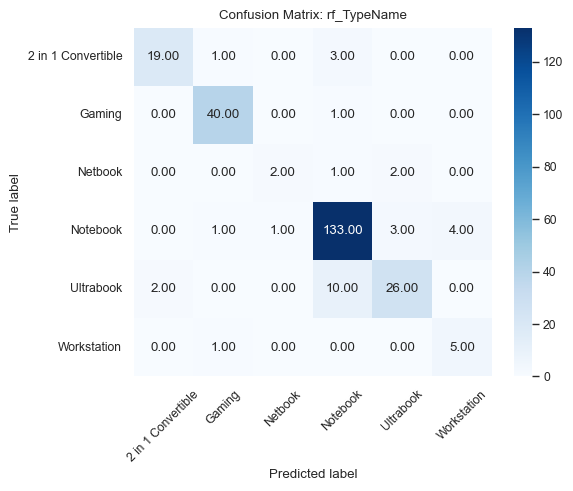

In [6]:
best_model_name = ranked.index[0]

fig, ax = plt.subplots(figsize=(6, 5))
confusion_matrix=results[best_model_name]['confusion_matrix']
display_labels=results[best_model_name]['classes']
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=display_labels,
    yticklabels=display_labels,
    cbar=True,
    ax=ax
)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.tick_params(axis='x', rotation=45)
ax.set_title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()

# plt.savefig('../Results/confusion_matrix_best_model.png', dpi=300)
plt.show()

## 4. What is NOT bulletproof yet

1. **Single split, still.** Every metric here is downstream of the one 80/20 split from
   `Classification_models.ipynb`. None of these numbers have a confidence interval or a
   cross-validated estimate — they're point estimates from one roll of the dice.
2. **Cohen's Kappa and MCC were bolted on after the fact** (`add_extra_metrics`), not computed at
   training time. That's a code smell: two functions now need to agree on what `results[col_name]`
   looks like. If `classification_functions.py` changes its dict keys, this notebook breaks
   silently at a `KeyError`, not obviously.
3. **No statistical test for "is model A actually better than model B"** — the MCC ranking above
   is a point-estimate ordering, not a significance claim. A paired test (e.g. McNemar's test on
   the two models' predictions) is the actual next step before you claim one model "wins".